We clustered Taylor Swift's music based on musical features; we also clustered her music based on text. This leads to one thing: cluster using both sets of features.

For this project, I will use Priester's dataset again, along with the SentenceTransformer cluster labels derived in a different notebook.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [8]:
# start with Priester's data
df = pd.read_csv('/kaggle/input/datasets/jarredpriester/taylor-swift-spotify-dataset/taylor_swift_spotify.csv')
df = df.drop(['Unnamed: 0', 'release_date', 'track_number', 'id', 'uri', 'popularity', 'instrumentalness'], axis=1)
df = df[df['album'] != 'reputation Stadium Tour Surprise Song Playlist']
df = df.drop_duplicates('name')

# map song names to the format in my data
def convert_name(name):
    #get rid of spaces
    name = re.sub(r" ", "", name)

    #get rid of apostrophes
    name = re.sub(r"['’]", "", name)

    #change punctuation to underscore
    name = re.sub(r"[()?.,-]", "_", name)

    return name

df['name'] = df['name'].map(convert_name)
# import my data
clusterdf = pd.read_csv('/kaggle/input/datasets/lewisssst/ts-lyric-clusters/lyric_clusters.csv')
clusterdf = clusterdf.drop('TFcluster', axis=1)

# renaming of clusters and columns 
clusterdf['STcluster'] = clusterdf['STcluster'].map({0: 'glitter_gel', 1: 'quill', 2: 'fountain'})
clusterdf = clusterdf.rename(columns={'song': 'name'})

# join
df = df.merge(clusterdf, on='name')
len(df)

183

We only have 183 datapoints, but this will still offer meaningful clusterings. Likely due to not analysing Taylor's Version separately - this can be improved.

One more data cleaning step - the clusters are named 0, 1, and 2. However, we should assume these clusters are equidistant from each other ($d(0, 2) = d(1, 2) = d(0, 1)$). So we use OHE.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# preprocessing of data
numeric = ['acousticness', 'danceability', 'energy', 'liveness', 'loudness', 'tempo', 'valence', 'duration_ms']
categorical = ['STcluster']

preprocess = ColumnTransformer(transformers=[('num', StandardScaler(), numeric), ('cat', OneHotEncoder(), categorical)])

X = preprocess.fit_transform(df)

Only K-Means is explored in this part of the project.

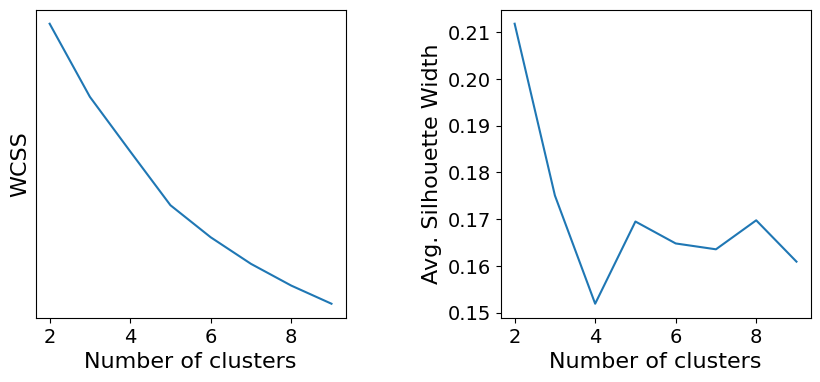

In [10]:
WCSS = []
silhouette = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=67, n_init=500)
    kmeans.fit(X)
    WCSS.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, kmeans.labels_))

nclusters = np.arange(2, 10, 1)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

ax1.plot(nclusters, WCSS)
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('WCSS')
ax1.set_yticks([])

ax2.plot(nclusters, silhouette)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Avg. Silhouette Width')

fig.subplots_adjust(wspace=0.5)
plt.show()

Fitting the model with 2 clusters.

In [12]:
kmeans = KMeans(n_clusters=2, random_state=67, n_init=500)
kmeans.fit(X)

from collections import Counter
Counter(kmeans.labels_)

Counter({np.int32(1): 82, np.int32(0): 101})

In [13]:
# create DF for analysis
analysisdf = pd.DataFrame({'name': df['name'], 'label': kmeans.labels_})
analysisdf[analysisdf['label']==1].head()

,name,label
0,TheTorturedPoetsDepartment,1
2,DownBad,1
3,SoLong_London,1
5,FreshOutTheSlammer,1
6,GuiltyasSin_,1


By inspection, 0 is sad and 1 is happy, like before.

I want to compare these labels to the ones I originally had with K-Means (only musical features).

In [14]:
# import the original K-Means labels
musickmeans = pd.read_csv('/kaggle/input/datasets/lewisssst/musical-features-kmeans/kmeanslabels.csv')
musickmeans['song'] = musickmeans['song'].map(convert_name)
musickmeans = musickmeans.rename(columns={'song': 'name'})

# merge the DFs
analysisdf = analysisdf.merge(musickmeans, on='name')
analysisdf = analysisdf.rename(columns={'label': 'music_lyrics', 'K-Means': 'music_only'})

Here are the differences:

In [16]:
analysisdf['music_lyrics'] = analysisdf['music_lyrics'].map({0: 'happy', 1: 'sad'})
analysisdf[analysisdf['music_lyrics'] != analysisdf['music_only']]

,name,music_lyrics,music_only
0,TheTorturedPoetsDepartment,sad,happy
45,NowThatWeDontTalk_TaylorsVersion__FromTheVault_,sad,happy
68,Maroon,sad,happy
72,Question____,sad,happy
115,TheBestDay_TaylorsVersion_,happy,sad
133,cardigan,happy,sad
151,TheArcher,sad,happy
171,CallItWhatYouWant,happy,sad


Using contextual knowledge:

Improved: TTPD, Maroon, Question, The Best Day, The Archer, CIWYW (75%)

Worsened: cardigan (12.5%)

Unclear: NTWDT (12.5%)

8 changes out of 183 data points suggests that the original clustering was already strong, and that Swift's music generally fits the lyrics well. 